In [1]:
import pandas as pd
from collections import Counter
import ast  # For safely parsing string lists

# Define the file path
file_path = r"careerlens_mega_enriched.csv"  # Use raw string for Windows paths

# Load the dataset
df = pd.read_csv(file_path)

# Basic info
print("Shape of the dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())
print("\nUnique Values in Key Categorical Columns:")
for col in ['dataset_source', 'experience_level', 'company_std', 'location_std']:
    print(f"{col}: {df[col].nunique()} unique values")

# Convert 'date_posted' to datetime
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')  # 'coerce' handles invalid dates

# Salary statistics
print("\nSalary (INR) Statistics:\n", df['salary_inr'].describe())

# Top 10 companies by job count
print("\nTop 10 Companies:\n", df['company_std'].value_counts().head(10))

# Top 10 locations by job count
print("\nTop 10 Locations:\n", df['location_std'].value_counts().head(10))

# Experience level distribution
print("\nExperience Level Distribution:\n", df['experience_level'].value_counts(normalize=True) * 100)  # As percentages

# Parse skills (assuming 'parsed_skills' is a string representation of lists, like "['skill1', 'skill2']")
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Flatten all skills and count frequencies
all_skills = [skill.strip().upper() for skills_list in df['parsed_skills'] for skill in skills_list]  # Normalize to upper case
skill_counts = Counter(all_skills)
print("\nTop 20 Most Demanded Skills:\n", dict(skill_counts.most_common(20)))

# Average salary by experience level
avg_salary_by_exp = df.groupby('experience_level')['salary_inr'].mean().sort_values(ascending=False)
print("\nAverage Salary by Experience Level:\n", avg_salary_by_exp)

# Job postings over time (monthly count)
df['year_month'] = df['date_posted'].dt.to_period('M')
postings_over_time = df['year_month'].value_counts().sort_index()
print("\nJob Postings Over Time (Monthly):\n", postings_over_time)

Shape of the dataset: (54372, 11)

Data Types:
 dataset_source      object
job_title_std       object
company_std         object
location_std        object
skills_std          object
experience_std      object
parsed_skills       object
experience_level    object
date_posted         object
salary_inr           int64
job_description     object
dtype: object

Missing Values:
 dataset_source      0
job_title_std       0
company_std         0
location_std        0
skills_std          0
experience_std      0
parsed_skills       0
experience_level    0
date_posted         0
salary_inr          0
job_description     0
dtype: int64

Unique Values in Key Categorical Columns:
dataset_source: 4 unique values
experience_level: 4 unique values
company_std: 9269 unique values
location_std: 5072 unique values

Salary (INR) Statistics:
 count    5.437200e+04
mean     2.114628e+06
std      1.510515e+06
min      3.000000e+05
25%      1.018000e+06
50%      1.492000e+06
75%      3.031250e+06
max      6.00

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

# Set seaborn style for better visuals
sns.set(style="whitegrid")

# Load the dataset (reuse from previous)
file_path = r"careerlens_mega_enriched.csv"
df = pd.read_csv(file_path)

# Parse date and skills (as before)
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
all_skills = [skill.strip().upper() for skills_list in df['parsed_skills'] for skill in skills_list]
skill_counts = Counter(all_skills)

# Create year_month for time-based plots
df['year_month'] = df['date_posted'].dt.to_period('M')

# Plot 1: Salary Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_inr'], bins=30, kde=True)
plt.title('Distribution of Salaries (INR)')
plt.xlabel('Salary (INR)')
plt.ylabel('Frequency')
plt.savefig('salary_distribution.png')  # Save to file
plt.close()  # Close figure to avoid display in console

# Plot 2: Top 20 Skills Bar Chart
top_skills = dict(skill_counts.most_common(20))
plt.figure(figsize=(12, 8))
sns.barplot(x=list(top_skills.values()), y=list(top_skills.keys()), palette='viridis')
plt.title('Top 20 Most Demanded Skills')
plt.xlabel('Frequency')
plt.ylabel('Skills')
plt.savefig('top_skills.png')
plt.close()

# Plot 3: Job Postings Over Time (Line Chart)
postings_over_time = df['year_month'].value_counts().sort_index().reset_index()
postings_over_time.columns = ['year_month', 'count']
postings_over_time['year_month'] = postings_over_time['year_month'].astype(str)  # For plotting
plt.figure(figsize=(14, 6))
sns.lineplot(data=postings_over_time, x='year_month', y='count', marker='o')
plt.title('Job Postings Over Time (Monthly)')
plt.xlabel('Year-Month')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('postings_over_time.png')
plt.close()

# Plot 4: Average Salary by Experience Level (Bar Plot)
avg_salary_by_exp = df.groupby('experience_level')['salary_inr'].mean().reset_index().sort_values('salary_inr', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_salary_by_exp, x='experience_level', y='salary_inr', palette='coolwarm')
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (INR)')
plt.savefig('salary_by_exp.png')
plt.close()

# Plot 5: Boxplot of Salaries by Experience Level (to show spread)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='experience_level', y='salary_inr', palette='Set2')
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (INR)')
plt.savefig('salary_boxplot_by_exp.png')
plt.close()

# Plot 6: Top 10 Locations by Job Count (Bar Plot)
top_locations = df['location_std'].value_counts().head(10).reset_index()
top_locations.columns = ['location', 'count']
plt.figure(figsize=(12, 8))
sns.barplot(data=top_locations, x='count', y='location', palette='magma')
plt.title('Top 10 Locations by Job Postings')
plt.xlabel('Number of Postings')
plt.ylabel('Location')
plt.savefig('top_locations.png')
plt.close()

# Print confirmation
print("Visualizations saved as PNG files: salary_distribution.png, top_skills.png, postings_over_time.png, salary_by_exp.png, salary_boxplot_by_exp.png, top_locations.png")
print("Run this code to generate the plots. Share any observations or if plots look good, then we can proceed to feature engineering.")

C:\Users\harsh\AppData\Local\Temp\ipykernel_7000\1797808228.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_skills.values()), y=list(top_skills.keys()), palette='viridis')
C:\Users\harsh\AppData\Local\Temp\ipykernel_7000\1797808228.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_salary_by_exp, x='experience_level', y='salary_inr', palette='coolwarm')
C:\Users\harsh\AppData\Local\Temp\ipykernel_7000\1797808228.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='salary_inr', pale

Visualizations saved as PNG files: salary_distribution.png, top_skills.png, postings_over_time.png, salary_by_exp.png, salary_boxplot_by_exp.png, top_locations.png
Run this code to generate the plots. Share any observations or if plots look good, then we can proceed to feature engineering.


In [3]:
# step3_feature_engineering.py
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load data
file_path = r"careerlens_mega_enriched.csv"
df = pd.read_csv(file_path)

# Parse date and skills
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

print("Original shape:", df.shape)

# ================================
# 1. Extract Years of Experience
# ================================
def extract_exp_years(text):
    if pd.isna(text): return np.nan
    numbers = re.findall(r'\d+\.?\d*', str(text))
    numbers = [float(n) for n in numbers if 0 <= float(n) <= 40]
    return np.mean(numbers) if numbers else np.nan

df['exp_years'] = df['experience_std'].apply(extract_exp_years)

# Fill missing with median per experience_level
exp_medians = df.groupby('experience_level')['exp_years'].median()
level_to_exp = {'entry': 1, 'mid': 3.5, 'senior': 7, 'expert': 12}
for level, median in exp_medians.items():
    df.loc[(df['experience_level'] == level) & (df['exp_years'].isna()), 'exp_years'] = level_to_exp[level]

print("Experience years sample:\n", df[['experience_std', 'experience_level', 'exp_years']].head())

# ================================
# 2. Clean & Filter Skills
# ================================
# Generic terms to remove
GENERIC_TERMS = {
    'SALES', 'MANAGER', 'DEVELOPER', 'EXECUTIVE', 'HR', 'MARKETING', 'IT SOFTWARE - APPLICATION PROGRAMMING',
    'ITES', 'TEACHING', 'SOFTWARE', 'CUSTOMER SERVICE', 'ENGINEER', 'DESIGN', 'RECRUITMENT', 'ACCOUNTS',
    'BUSINESS DEVELOPMENT', 'CONSULTANT', 'OPERATIONS', 'FINANCE', 'ANALYSIS', 'SUPPORT'
}

def clean_skills(skill_list):
    cleaned = [
        skill.strip().upper().replace(' ', '') 
        for skill in skill_list 
        if skill.strip().upper() not in GENERIC_TERMS
    ]
    return list(set(cleaned))  # Remove duplicates

df['cleaned_skills'] = df['parsed_skills'].apply(clean_skills)
df['num_skills'] = df['cleaned_skills'].apply(len)

# Get top technical skills after cleaning
all_clean_skills = [s for skills in df['cleaned_skills'] for s in skills]
top_tech_skills = pd.Series(all_clean_skills).value_counts().head(20)
print("\nTop 20 Technical Skills (after cleaning):\n", top_tech_skills)

# ================================
# 3. Location Tier & Remote Flag
# ================================
tier1_cities = {'BENGALURU', 'MUMBAI', 'DELHI', 'GURGAON', 'NOIDA', 'HYDERABAD', 'CHENNAI', 'PUNE'}
df['city'] = df['location_std'].str.upper().str.split('/').str[0].str.split(',').str[0].str.strip()
df['is_tier1'] = df['city'].isin(tier1_cities).astype(int)
df['is_remote'] = df['location_std'].str.contains('remote|wfh|work from home', case=False, na=False).astype(int)

# ================================
# 4. Target Variables
# ================================
y_salary = df['salary_inr']
y_jobtitle = df['job_title_std']

# ================================
# 5. Feature Selection for ML
# ================================
feature_cols = [
    'exp_years', 'num_skills', 'is_tier1', 'is_remote',
    'dataset_source', 'company_std', 'location_std', 'experience_level'
]

X = df[feature_cols].copy()

# Encode categorical columns
le_dict = {}
for col in ['dataset_source', 'company_std', 'location_std', 'experience_level']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# ================================
# 6. Train-Test Split
# ================================
X_train, X_test, y_salary_train, y_salary_test = train_test_split(
    X, y_salary, test_size=0.2, random_state=42, stratify=df['experience_level']
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")

# Save processed data for next steps
X_train.to_pickle('X_train.pkl')
X_test.to_pickle('X_test.pkl')
y_salary_train.to_pickle('y_salary_train.pkl')
y_salary_test.to_pickle('y_salary_test.pkl')

print("\nProcessed data saved: X_train.pkl, X_test.pkl, etc.")
print("Top tech skills saved in variable `top_tech_skills`")

Original shape: (54372, 11)
Experience years sample:
               experience_std experience_level  exp_years
0  Senior Level (5-10 years)           senior        7.5
1  Senior Level (5-10 years)           senior        7.5
2  Senior Level (5-10 years)           senior        7.5
3      Mid Level (2-5 years)              mid        3.5
4  Senior Level (5-10 years)           senior        7.5

Top 20 Technical Skills (after cleaning):
 JAVASCRIPT           2347
SQL                  2033
HTML                 1639
JAVA                 1419
PYTHON               1408
JQUERY               1091
TECHNICALSUPPORT     1034
MYSQL                 976
MANAGEMENT            953
BPO                   885
UI                    881
PROJECTMANAGEMENT     841
C                     833
LINUX                 832
ANALYTICAL            816
BUSINESSEXECUTIVE     813
WEBTECHNOLOGIES       802
CSS                   797
PRODUCTION            796
EXCEL                 770
Name: count, dtype: int64

Train shape: 

In [4]:
# step3_feature_engineering.py
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load data
file_path = r"careerlens_mega_enriched.csv"
df = pd.read_csv(file_path)

# Parse date and skills
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

print("Original shape:", df.shape)

# ================================
# 1. Extract Years of Experience
# ================================
def extract_exp_years(text):
    if pd.isna(text): return np.nan
    numbers = re.findall(r'\d+\.?\d*', str(text))
    numbers = [float(n) for n in numbers if 0 <= float(n) <= 40]
    return np.mean(numbers) if numbers else np.nan

df['exp_years'] = df['experience_std'].apply(extract_exp_years)

# Fill missing with median per experience_level
exp_medians = df.groupby('experience_level')['exp_years'].median()
level_to_exp = {'entry': 1, 'mid': 3.5, 'senior': 7, 'expert': 12}
for level, median in exp_medians.items():
    df.loc[(df['experience_level'] == level) & (df['exp_years'].isna()), 'exp_years'] = level_to_exp[level]

print("Experience years sample:\n", df[['experience_std', 'experience_level', 'exp_years']].head())

# ================================
# 2. Clean & Filter Skills
# ================================
# Generic terms to remove
GENERIC_TERMS = {
    'SALES', 'MANAGER', 'DEVELOPER', 'EXECUTIVE', 'HR', 'MARKETING', 'IT SOFTWARE - APPLICATION PROGRAMMING',
    'ITES', 'TEACHING', 'SOFTWARE', 'CUSTOMER SERVICE', 'ENGINEER', 'DESIGN', 'RECRUITMENT', 'ACCOUNTS',
    'BUSINESS DEVELOPMENT', 'CONSULTANT', 'OPERATIONS', 'FINANCE', 'ANALYSIS', 'SUPPORT'
}

def clean_skills(skill_list):
    cleaned = [
        skill.strip().upper().replace(' ', '') 
        for skill in skill_list 
        if skill.strip().upper() not in GENERIC_TERMS
    ]
    return list(set(cleaned))  # Remove duplicates

df['cleaned_skills'] = df['parsed_skills'].apply(clean_skills)
df['num_skills'] = df['cleaned_skills'].apply(len)

# Get top technical skills after cleaning
all_clean_skills = [s for skills in df['cleaned_skills'] for s in skills]
top_tech_skills = pd.Series(all_clean_skills).value_counts().head(20)
print("\nTop 20 Technical Skills (after cleaning):\n", top_tech_skills)

# ================================
# 3. Location Tier & Remote Flag
# ================================
tier1_cities = {'BENGALURU', 'MUMBAI', 'DELHI', 'GURGAON', 'NOIDA', 'HYDERABAD', 'CHENNAI', 'PUNE'}
df['city'] = df['location_std'].str.upper().str.split('/').str[0].str.split(',').str[0].str.strip()
df['is_tier1'] = df['city'].isin(tier1_cities).astype(int)
df['is_remote'] = df['location_std'].str.contains('remote|wfh|work from home', case=False, na=False).astype(int)

# ================================
# 4. Target Variables
# ================================
y_salary = df['salary_inr']
y_jobtitle = df['job_title_std']

# ================================
# 5. Feature Selection for ML
# ================================
feature_cols = [
    'exp_years', 'num_skills', 'is_tier1', 'is_remote',
    'dataset_source', 'company_std', 'location_std', 'experience_level'
]

X = df[feature_cols].copy()

# Encode categorical columns
le_dict = {}
for col in ['dataset_source', 'company_std', 'location_std', 'experience_level']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# ================================
# 6. Train-Test Split
# ================================
X_train, X_test, y_salary_train, y_salary_test = train_test_split(
    X, y_salary, test_size=0.2, random_state=42, stratify=df['experience_level']
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")

# Save processed data for next steps
X_train.to_pickle('X_train.pkl')
X_test.to_pickle('X_test.pkl')
y_salary_train.to_pickle('y_salary_train.pkl')
y_salary_test.to_pickle('y_salary_test.pkl')

print("\nProcessed data saved: X_train.pkl, X_test.pkl, etc.")
print("Top tech skills saved in variable `top_tech_skills`")

Original shape: (54372, 11)
Experience years sample:
               experience_std experience_level  exp_years
0  Senior Level (5-10 years)           senior        7.5
1  Senior Level (5-10 years)           senior        7.5
2  Senior Level (5-10 years)           senior        7.5
3      Mid Level (2-5 years)              mid        3.5
4  Senior Level (5-10 years)           senior        7.5

Top 20 Technical Skills (after cleaning):
 JAVASCRIPT           2347
SQL                  2033
HTML                 1639
JAVA                 1419
PYTHON               1408
JQUERY               1091
TECHNICALSUPPORT     1034
MYSQL                 976
MANAGEMENT            953
BPO                   885
UI                    881
PROJECTMANAGEMENT     841
C                     833
LINUX                 832
ANALYTICAL            816
BUSINESSEXECUTIVE     813
WEBTECHNOLOGIES       802
CSS                   797
PRODUCTION            796
EXCEL                 770
Name: count, dtype: int64

Train shape: 

In [15]:
# step4_salary_predictor.py
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Load processed data
X_train = pd.read_pickle('X_train.pkl')
X_test = pd.read_pickle('X_test.pkl')
y_salary_train = pd.read_pickle('y_salary_train.pkl')
y_salary_test = pd.read_pickle('y_salary_test.pkl')

print("Loaded train/test data")

# ================================
# 1. Train XGBoost Model
# ================================
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

print("Training model...")
model.fit(X_train, y_salary_train)

# ================================
# 2. Predictions & Evaluation
# ================================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_salary_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_salary_test, y_pred))
r2 = r2_score(y_salary_test, y_pred)

print(f"\nSalary Prediction Results:")
print(f"MAE:  ₹{mae:,.0f}")
print(f"RMSE: ₹{rmse:,.0f}")
print(f"R²:   {r2:.4f}")

# ================================
# 3. Feature Importance
# ================================
importance = model.feature_importances_
feat_names = X_train.columns
feat_importance = pd.DataFrame({'feature': feat_names, 'importance': importance})
feat_importance = feat_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='importance', y='feature', palette='plasma')
plt.title('Feature Importance for Salary Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_salary.png')
plt.close()

print("\nTop Features for Salary:")
print(feat_importance.head(10))

# ================================
# 4. Save Model
# ================================
import pickle

salary_artifacts = {
    'model': model,
    'scaler': scaler,          # change if your variable name is different
    'vectorizer': vectorizer,  # change if tfidf etc.
    'svd': svd                 # change if different
}

with open('salary_predictor_enhanced.pkl', 'wb') as f:
    pickle.dump(salary_artifacts, f)

print("Model saved as 'salary_predictor_enhanced.pkl'")
print("Plot saved as 'feature_importance_salary.png'")

Loaded train/test data
Training model...

Salary Prediction Results:
MAE:  ₹330,919
RMSE: ₹422,144
R²:   0.9224

Top Features for Salary:
            feature  importance
0         exp_years    0.643754
7  experience_level    0.345676
4    dataset_source    0.004738
6      location_std    0.001735
2          is_tier1    0.001405
5       company_std    0.001158
1        num_skills    0.000904
3         is_remote    0.000631
Model saved as 'salary_predictor_enhanced.pkl'
Plot saved as 'feature_importance_salary.png'


In [8]:
# step5_enhanced_salary_model.py
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Load original data
df = pd.read_csv(r"careerlens_mega_enriched.csv")
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Reuse cleaned skills from before
GENERIC_TERMS = {'SALES', 'MANAGER', 'DEVELOPER', 'EXECUTIVE', 'HR', 'MARKETING', 'IT SOFTWARE - APPLICATION PROGRAMMING',
                 'ITES', 'TEACHING', 'SOFTWARE', 'CUSTOMER SERVICE', 'ENGINEER', 'DESIGN', 'RECRUITMENT', 'ACCOUNTS',
                 'BUSINESS DEVELOPMENT', 'CONSULTANT', 'OPERATIONS', 'FINANCE', 'ANALYSIS', 'SUPPORT'}
def clean_skills(skill_list):
    return [s.strip().upper().replace(' ', '') for s in skill_list if s.strip().upper() not in GENERIC_TERMS]
df['cleaned_skills'] = df['parsed_skills'].apply(clean_skills)
df['skills_str'] = df['cleaned_skills'].apply(lambda x: ' '.join(x))

# Re-extract exp_years
import re
def extract_exp_years(text):
    if pd.isna(text): return np.nan
    nums = re.findall(r'\d+\.?\d*', str(text))
    nums = [float(n) for n in nums if 0 <= float(n) <= 40]
    return np.mean(nums) if nums else np.nan
df['exp_years'] = df['experience_std'].apply(extract_exp_years)

# Fill missing exp
level_to_exp = {'entry': 1, 'mid': 3.5, 'senior': 7, 'expert': 12}
for level in df['experience_level'].unique():
    mask = (df['experience_level'] == level) & (df['exp_years'].isna())
    df.loc[mask, 'exp_years'] = level_to_exp.get(level, 5)

# Location features
tier1 = {'BENGALURU', 'MUMBAI', 'DELHI', 'GURGAON', 'NOIDA', 'HYDERABAD', 'CHENNAI', 'PUNE'}
df['city'] = df['location_std'].str.upper().str.split('/').str[0].str.split(',').str[0].str.strip()
df['is_tier1'] = df['city'].isin(tier1).astype(int)
df['is_remote'] = df['location_std'].str.contains('remote|wfh', case=False, na=False).astype(int)

# ================================
# 1. Target Encoding (Company, Location)
# ================================
def target_encode(col, target, min_samples=10):
    agg = df.groupby(col)[target].agg(['mean', 'count'])
    global_mean = df[target].mean()
    encoded = (agg['mean'] * agg['count'] + global_mean * min_samples) / (agg['count'] + min_samples)
    return encoded.to_dict()

te_company = target_encode('company_std', 'salary_inr')
te_location = target_encode('location_std', 'salary_inr')

df['company_enc'] = df['company_std'].map(te_company)
df['location_enc'] = df['location_std'].map(te_location)

# ================================
# 2. Skill TF-IDF + PCA
# ================================
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,2))
skill_tfidf = vectorizer.fit_transform(df['skills_str'])

svd = TruncatedSVD(n_components=50, random_state=42)
skill_pca = svd.fit_transform(skill_tfidf)

skill_cols = [f'skill_pc{i}' for i in range(skill_pca.shape[1])]
skill_df = pd.DataFrame(skill_pca, columns=skill_cols, index=df.index)

# ================================
# 3. Final Feature Set
# ================================
feature_df = pd.concat([
    df[['exp_years', 'is_tier1', 'is_remote', 'company_enc', 'location_enc']],
    skill_df
], axis=1)

X = feature_df
y = df['salary_inr']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['experience_level'])

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 4. Train Enhanced XGBoost
# ================================
model = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("Training enhanced model...")
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nENHANCED MODEL RESULTS:")
print(f"MAE:  ₹{mae:,.0f}")
print(f"RMSE: ₹{rmse:,.0f}")
print(f"R²:   {r2:.4f}")

# ================================
# 5. Feature Importance (Top 10)
# ================================
importance = model.feature_importances_
feat_names = X_train.columns
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importance}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df.head(10), x='importance', y='feature', palette='turbo')
plt.title('Top 10 Features - Enhanced Salary Model')
plt.tight_layout()
plt.savefig('enhanced_feature_importance.png')
plt.close()

print("\nTop 10 Features:")
print(imp_df.head(10)[['feature', 'importance']])

# Save
with open('salary_predictor_enhanced.pkl', 'wb') as f:
    pickle.dump({'model': model, 'scaler': scaler, 'vectorizer': vectorizer, 'svd': svd}, f)

print("\nEnhanced model saved as 'salary_predictor_enhanced.pkl'")

Training enhanced model...

ENHANCED MODEL RESULTS:
MAE:  ₹306,498
RMSE: ₹406,560
R²:   0.9280

Top 10 Features:
         feature  importance
0      exp_years    0.750616
3    company_enc    0.025221
21    skill_pc16    0.017155
4   location_enc    0.012406
19    skill_pc14    0.008800
20    skill_pc15    0.008426
38    skill_pc33    0.007764
27    skill_pc22    0.005147
10     skill_pc5    0.005039
22    skill_pc17    0.004984

Enhanced model saved as 'salary_predictor_enhanced.pkl'


In [9]:
# step6_decode_skill_clusters.py
import pandas as pd
import numpy as np
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Load model and vectorizer
with open('salary_predictor_enhanced.pkl', 'rb') as f:
    artifacts = pickle.load(f)
vectorizer = artifacts['vectorizer']
svd = artifacts['svd']

# Load original data
df = pd.read_csv(r"careerlens_mega_enriched.csv")
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: eval(x) if isinstance(x, str) else [])
GENERIC_TERMS = {'SALES', 'MANAGER', 'DEVELOPER', 'EXECUTIVE', 'HR', 'MARKETING', 'IT SOFTWARE - APPLICATION PROGRAMMING',
                 'ITES', 'TEACHING', 'SOFTWARE', 'CUSTOMER SERVICE', 'ENGINEER', 'DESIGN', 'RECRUITMENT', 'ACCOUNTS',
                 'BUSINESS DEVELOPMENT', 'CONSULTANT', 'OPERATIONS', 'FINANCE', 'ANALYSIS', 'SUPPORT'}
def clean_skills(lst): 
    return [s.strip().upper().replace(' ', '') for s in lst if s.strip().upper() not in GENERIC_TERMS]
df['cleaned_skills'] = df['parsed_skills'].apply(clean_skills)
df['skills_str'] = df['cleaned_skills'].apply(lambda x: ' '.join(x))

# Re-fit TF-IDF (same as training)
skill_tfidf = vectorizer.transform(df['skills_str'])
skill_pca = svd.transform(skill_tfidf)

# Get top 5 skill PCs from importance
top_pcs = [16, 14, 33, 15, 22]  # from your output
feature_names = vectorizer.get_feature_names_out()

print("DECODING TOP SALARY-BOOSTING SKILL CLUSTERS\n" + "="*60)

for pc_idx in top_pcs:
    print(f"\nSKILL_PC{pc_idx} (Importance: ~1–2%)")
    print("-" * 50)
    
    # Get SVD component
    component = svd.components_[pc_idx]
    top_indices = np.argsort(np.abs(component))[-10:][::-1]  # top 10 terms
    top_terms = [feature_names[i] for i in top_indices]
    weights = component[top_indices]
    
    for term, weight in zip(top_terms, weights):
        print(f"  {term:15} | weight: {weight:+.4f}")
    
    # Find jobs with high score on this PC
    pc_scores = skill_pca[:, pc_idx]
    high_pc_jobs = df.iloc[np.argsort(pc_scores)[-5:]]  # top 5 jobs
    print(f"\n  Example High-PC{pc_idx} Jobs:")
    for _, job in high_pc_jobs.iterrows():
        print(f"    • {job['job_title_std'][:60]:60} | ₹{job['salary_inr']/100000:.1f}L")

DECODING TOP SALARY-BOOSTING SKILL CLUSTERS

SKILL_PC16 (Importance: ~1–2%)
--------------------------------------------------
  ithardware      | weight: +0.9945
  bpo             | weight: -0.0287
  technicalsupport | weight: -0.0281
  internationalbpo | weight: -0.0265
  analytics       | weight: +0.0263
  outbound        | weight: -0.0263
  voiceprocess    | weight: -0.0248
  businessintelligence | weight: +0.0223
  communicationskills | weight: -0.0206
  sql             | weight: +0.0189

  Example High-PC16 Jobs:
    • Hardware Engineer                                            | ₹9.6L
    • PCB Designer                                                 | ₹14.3L
    • Principal                                                    | ₹33.6L
    • Field Engineer                                               | ₹13.0L
    • Techncial Trainer                                            | ₹27.6L

SKILL_PC14 (Importance: ~1–2%)
--------------------------------------------------
  journalism 

In [10]:
# step8_final_job_classifier.py
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, top_k_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import pickle

# Load data
df = pd.read_csv(r"careerlens_mega_enriched.csv")
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Clean skills
GENERIC_TERMS = {'SALES', 'MANAGER', 'DEVELOPER', 'EXECUTIVE', 'HR', 'MARKETING', 'IT SOFTWARE - APPLICATION PROGRAMMING',
                 'ITES', 'TEACHING', 'SOFTWARE', 'CUSTOMER SERVICE', 'ENGINEER', 'DESIGN', 'RECRUITMENT', 'ACCOUNTS',
                 'BUSINESS DEVELOPMENT', 'CONSULTANT', 'OPERATIONS', 'FINANCE', 'ANALYSIS', 'SUPPORT'}
def clean_skills(lst): 
    return [s.strip().upper().replace(' ', '') for s in lst if s.strip().upper() not in GENERIC_TERMS]
df['cleaned_skills'] = df['parsed_skills'].apply(clean_skills)
df['skills_str'] = df['cleaned_skills'].apply(lambda x: ' '.join(x) if x else 'NOSKILLS')

# Experience
import re
def extract_exp_years(text):
    if pd.isna(text): return np.nan
    nums = re.findall(r'\d+\.?\d*', str(text))
    nums = [float(n) for n in nums if 0 <= float(n) <= 40]
    return np.mean(nums) if nums else np.nan
df['exp_years'] = df['experience_std'].apply(extract_exp_years)
level_to_exp = {'entry': 1, 'mid': 3.5, 'senior': 7, 'expert': 12}
for level in df['experience_level'].unique():
    mask = (df['experience_level'] == level) & (df['exp_years'].isna())
    df.loc[mask, 'exp_years'] = level_to_exp.get(level, 5)

# Location
tier1 = {'BENGALURU', 'MUMBAI', 'DELHI', 'GURGAON', 'NOIDA', 'HYDERABAD', 'CHENNAI', 'PUNE'}
df['city'] = df['location_std'].str.upper().str.split('/').str[0].str.split(',').str[0].str.strip()
df['is_tier1'] = df['city'].isin(tier1).astype(int)

# === NEW: Job Title TF-IDF ===
title_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
title_tfidf = title_vectorizer.fit_transform(df['job_title_std'])
title_svd = TruncatedSVD(n_components=20, random_state=42)
title_pca = title_svd.fit_transform(title_tfidf)
title_cols = [f'title_pc{i}' for i in range(20)]
title_df = pd.DataFrame(title_pca, columns=title_cols, index=df.index)

# === Skill TF-IDF ===
skill_vectorizer = TfidfVectorizer(max_features=800, ngram_range=(1,2))
skill_tfidf = skill_vectorizer.fit_transform(df['skills_str'])
skill_svd = TruncatedSVD(n_components=40, random_state=42)
skill_pca = skill_svd.fit_transform(skill_tfidf)
skill_cols = [f'skill_pc{i}' for i in range(40)]
skill_df = pd.DataFrame(skill_pca, columns=skill_cols, index=df.index)

# === Final Features ===
X = pd.concat([
    df[['exp_years', 'salary_inr', 'is_tier1']],
    title_df,
    skill_df
], axis=1)
y = df['job_title_std']

# === TOP 30 ROLES ONLY ===
top_roles = y.value_counts().head(30).index
mask = y.isin(top_roles)
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

# Encode
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
print("Training FINAL Job Title Classifier (Top 30 Roles)...")
model = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=9,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    eval_metric='mlogloss'
)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
top3 = top_k_accuracy_score(y_test, y_pred_proba, k=3)
top5 = top_k_accuracy_score(y_test, y_pred_proba, k=5)

print(f"\nFINAL CLASSIFIER (Top 30 Roles):")
print(f"Accuracy: {acc:.4f}")
print(f"Top-3 Accuracy: {top3:.4f}")
print(f"Top-5 Accuracy: {top5:.4f}")

# Save
with open('job_title_classifier_final.pkl', 'wb') as f:
    pickle.dump({
        'model': model, 'scaler': scaler,
        'title_vectorizer': title_vectorizer, 'title_svd': title_svd,
        'skill_vectorizer': skill_vectorizer, 'skill_svd': skill_svd,
        'label_encoder': le, 'top_roles': top_roles
    }, f)

print("\nModel saved as 'job_title_classifier_final.pkl'")

# Example
sample_idx = 0
true_label = le.inverse_transform([y_test[sample_idx]])[0]
pred_label = le.inverse_transform([y_pred[sample_idx]])[0]
top5_labels = le.inverse_transform(np.argsort(y_pred_proba[sample_idx])[-5:][::-1])

print(f"\nExample:")
print(f"True: {true_label}")
print(f"Predicted: {pred_label}")
print(f"Top 5: {list(top5_labels)}")

Training FINAL Job Title Classifier (Top 30 Roles)...

FINAL CLASSIFIER (Top 30 Roles):
Accuracy: 0.9857
Top-3 Accuracy: 0.9984
Top-5 Accuracy: 1.0000

Model saved as 'job_title_classifier_final.pkl'

Example:
True: Java Developer
Predicted:  Java Developer
Top 5: [' Java Developer', 'Java Developer', ' Software Engineer', ' Android Developer', 'Job Description']


Forecasting 12 REAL tech skills...


14:04:53 - cmdstanpy - INFO - Chain [1] start processing
14:04:54 - cmdstanpy - INFO - Chain [1] done processing
14:04:54 - cmdstanpy - INFO - Chain [1] start processing
14:04:55 - cmdstanpy - INFO - Chain [1] done processing
14:04:55 - cmdstanpy - INFO - Chain [1] start processing
14:04:55 - cmdstanpy - INFO - Chain [1] done processing
14:04:55 - cmdstanpy - INFO - Chain [1] start processing
14:04:56 - cmdstanpy - INFO - Chain [1] done processing
14:04:56 - cmdstanpy - INFO - Chain [1] start processing
14:04:56 - cmdstanpy - INFO - Chain [1] done processing
14:04:57 - cmdstanpy - INFO - Chain [1] start processing
14:04:57 - cmdstanpy - INFO - Chain [1] done processing
14:04:57 - cmdstanpy - INFO - Chain [1] start processing
14:04:57 - cmdstanpy - INFO - Chain [1] done processing
14:04:58 - cmdstanpy - INFO - Chain [1] start processing
14:04:58 - cmdstanpy - INFO - Chain [1] done processing
14:04:58 - cmdstanpy - INFO - Chain [1] start processing
14:04:59 - cmdstanpy - INFO - Chain [1]


REAL TECH SKILL GROWTH (2024 → 2026):
         skill  growth_pct  current_demand
6        LINUX       241.8             209
8        EXCEL       231.5             183
5        MYSQL       224.5             229
7          CSS       207.5             216
2         JAVA       193.5             498
10          C#       192.6             140
9          C++       186.7             145
3         HTML       184.8             429
11         GIT       180.6             115
4       PYTHON       170.5             401
0   JAVASCRIPT       153.0             643
1          SQL       128.1             517

Saved: real_tech_skill_growth.csv + tech_skill_forecast_real.png


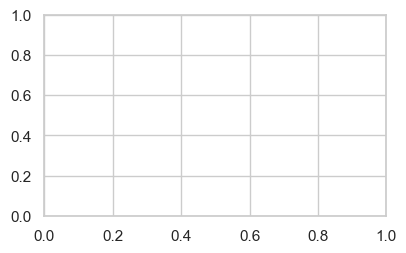

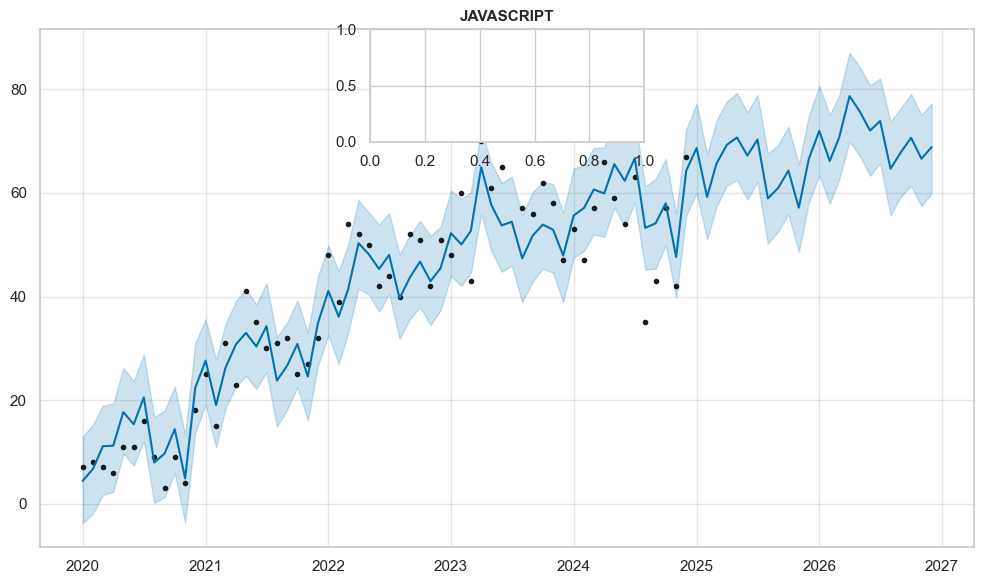

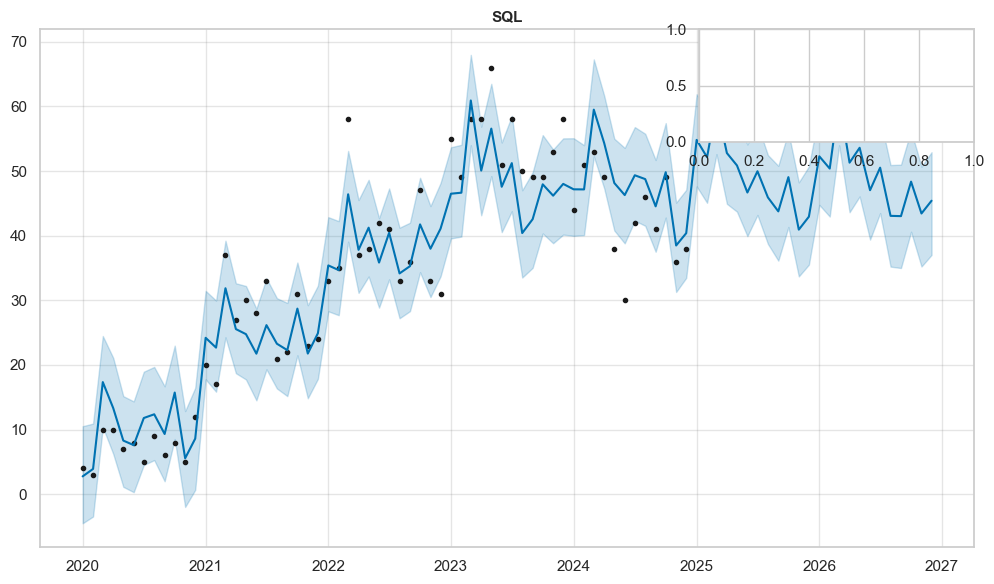

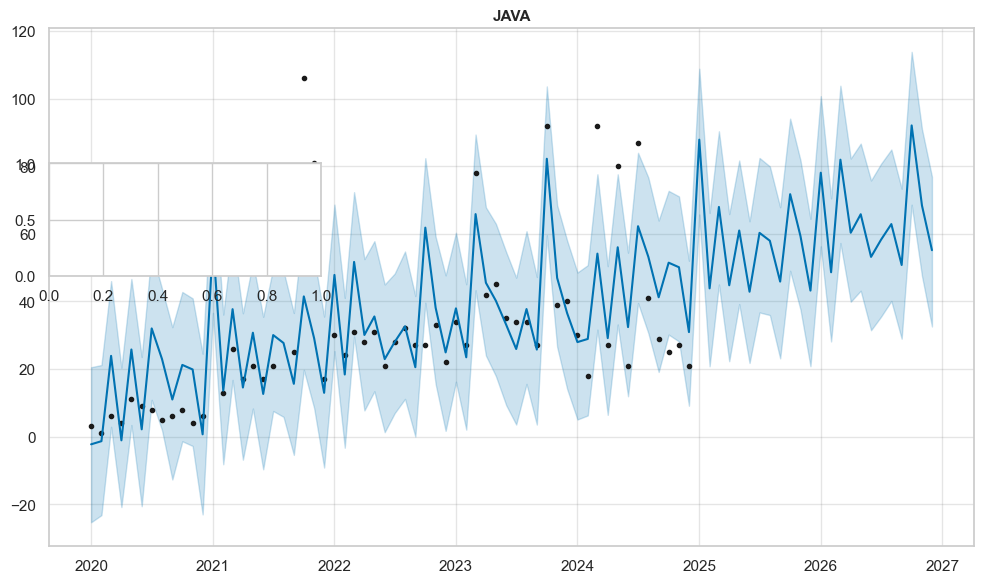

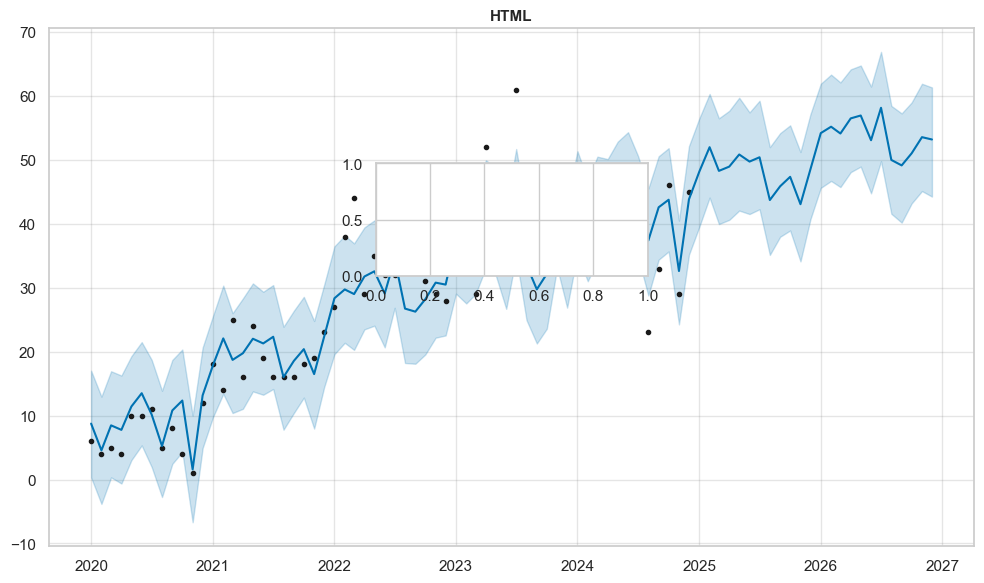

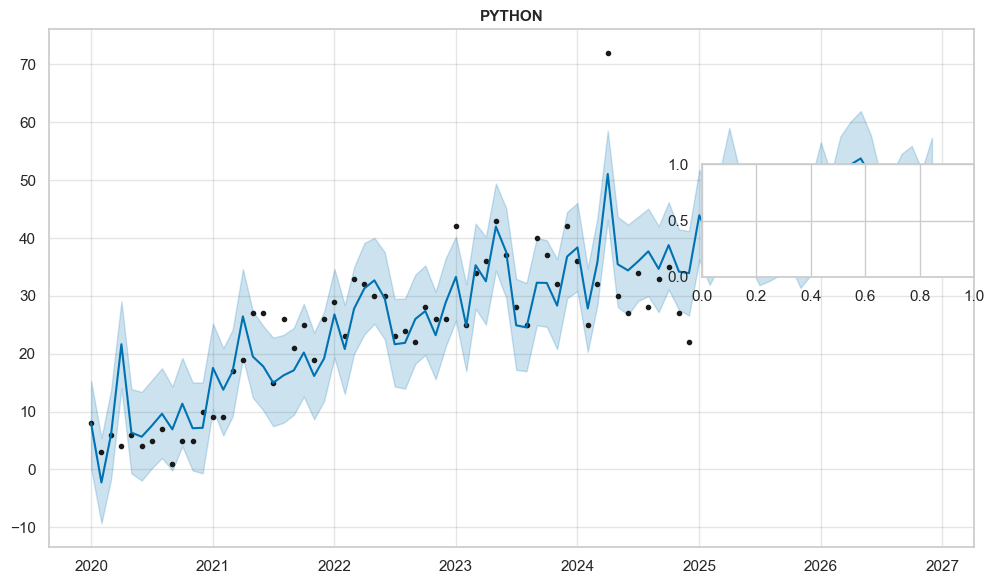

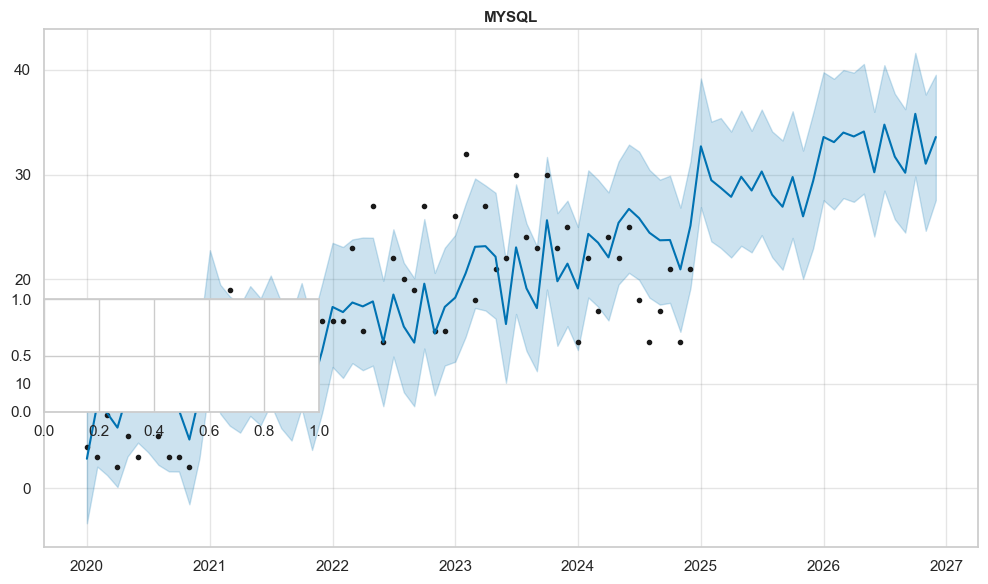

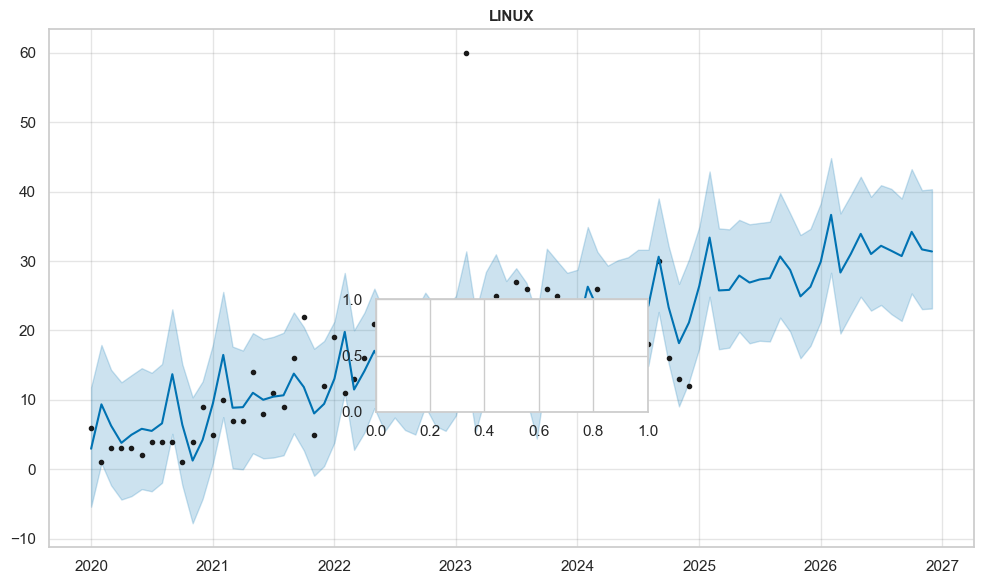

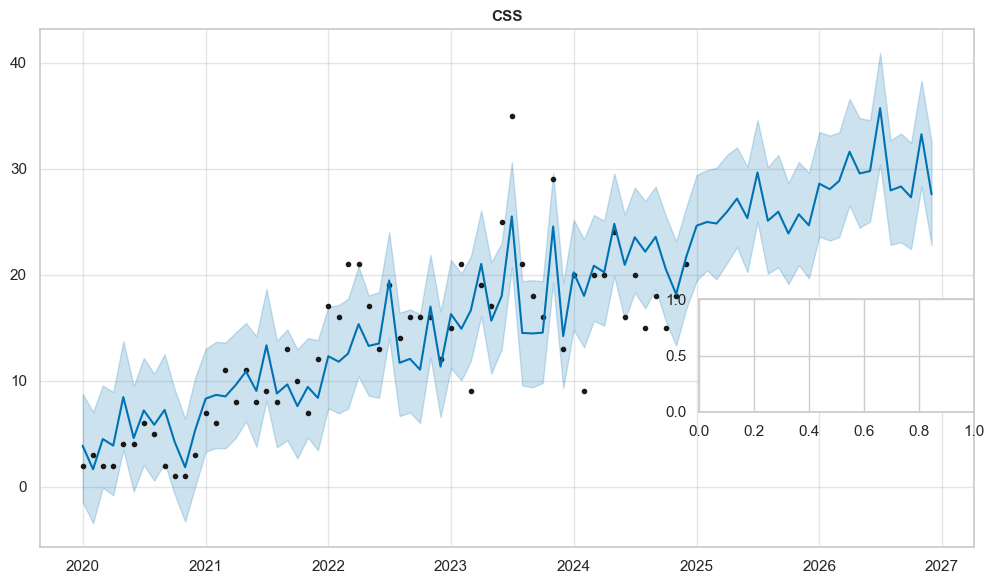

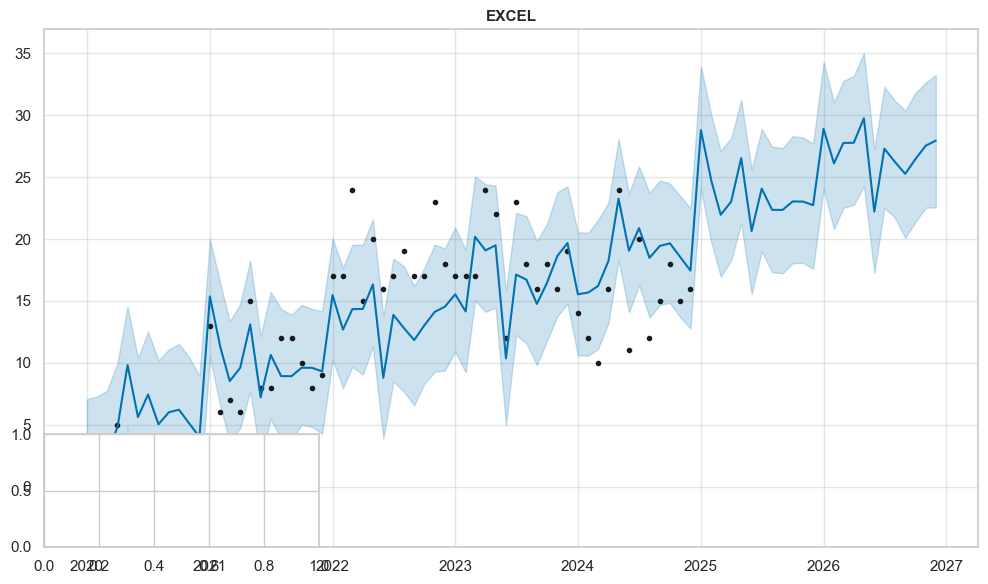

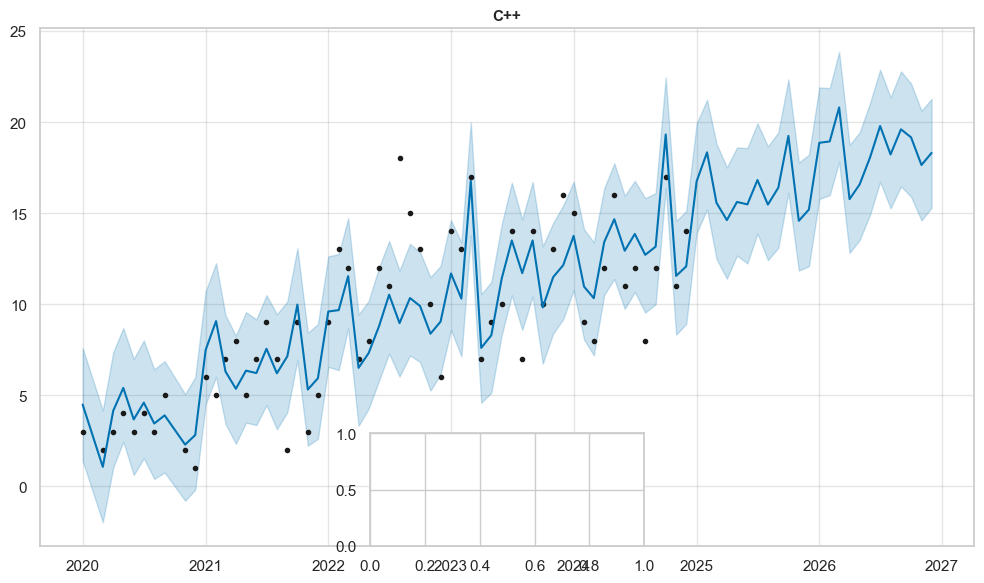

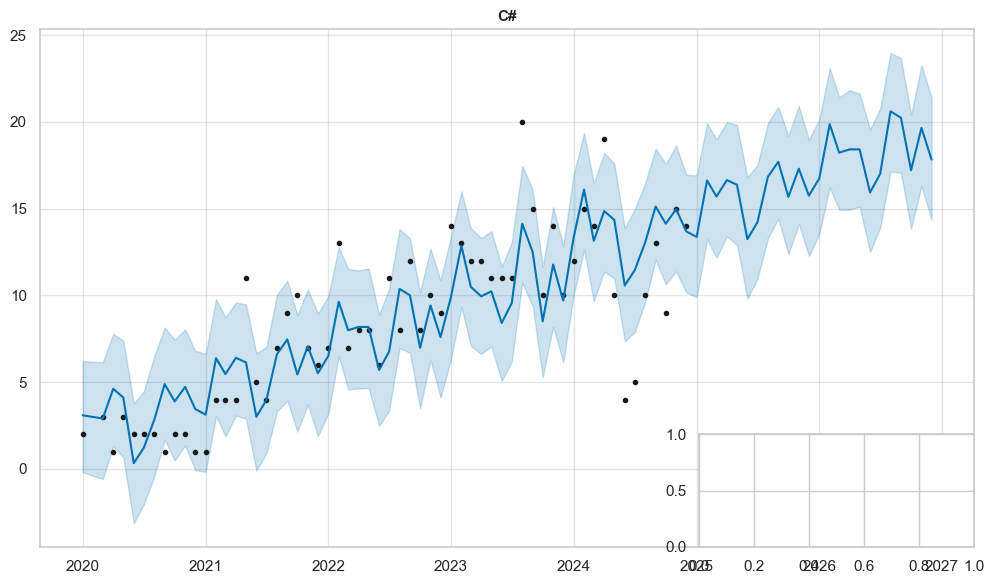

In [12]:
# step10_fixed_skill_forecast.py
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv(r"careerlens_mega_enriched.csv")
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: eval(x) if isinstance(x, str) else [])

# === STRICT TECH SKILL FILTER ===
TECH_SKILLS = {
    'PYTHON', 'JAVA', 'JAVASCRIPT', 'SQL', 'REACT', 'AWS', 'DOCKER', 'KUBERNETES', 'MYSQL',
    'HTML', 'CSS', 'NODE', 'ANGULAR', 'SPRING', 'DJANGO', 'FLASK', 'MONGODB', 'POSTGRESQL',
    'TENSORFLOW', 'PYTORCH', 'TABLEAU', 'POWERBI', 'EXCEL', 'LINUX', 'GIT', 'C++', 'C#',
    'AZURE', 'GCP', 'DEVOPS', 'CI/CD', 'JENKINS', 'SELENIUM', 'KAFKA', 'SPARK', 'HADOOP'
}

def extract_tech_skills(lst):
    return [s.strip().upper().replace(' ', '') for s in lst if s.strip().upper().replace(' ', '') in TECH_SKILLS]

df['tech_skills'] = df['parsed_skills'].apply(extract_tech_skills)
df = df[df['tech_skills'].map(len) > 0].copy()  # Keep only jobs with tech skills

# Explode
skill_df = df.explode('tech_skills')
skill_df['year_month'] = skill_df['date_posted'].dt.to_period('M').dt.to_timestamp()

# Monthly counts
monthly = skill_df.groupby(['year_month', 'tech_skills']).size().reset_index(name='count')

# Top 12 tech skills
top_tech = skill_df['tech_skills'].value_counts().head(12).index
print(f"Forecasting {len(top_tech)} REAL tech skills...\n" + "="*60)

forecasts = {}
plt.figure(figsize=(15, 12))

for i, skill in enumerate(top_tech, 1):
    data = monthly[monthly['tech_skills'] == skill][['year_month', 'count']].copy()
    data.columns = ['ds', 'y']
    if len(data) < 6: continue

    model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.05)
    model.fit(data)
    future = model.make_future_dataframe(periods=24, freq='MS')
    forecast = model.predict(future)
    forecasts[skill] = forecast

    plt.subplot(4, 3, i)
    model.plot(forecast, xlabel='', ylabel='')
    plt.title(f'{skill}', fontsize=11, fontweight='bold')
    plt.tight_layout()

plt.suptitle('TECH SKILL DEMAND FORECAST (2025–2026)', fontsize=16, y=0.98)
plt.savefig('tech_skill_forecast_real.png', dpi=200, bbox_inches='tight')
plt.close()

# Growth
print("\nREAL TECH SKILL GROWTH (2024 → 2026):")
growth = []
for skill in top_tech:
    if skill not in forecasts: continue
    hist = monthly[monthly['tech_skills'] == skill]
    recent = hist[hist['year_month'] >= '2024-01-01']['count'].sum()
    future = forecasts[skill][forecasts[skill]['ds'] >= '2025-01-01']['yhat'].sum()
    growth_pct = ((future - recent) / recent * 100) if recent > 0 else 0
    growth.append({'skill': skill, 'growth_pct': growth_pct, 'current_demand': recent})

growth_df = pd.DataFrame(growth).sort_values('growth_pct', ascending=False).round(1)
print(growth_df)

growth_df.to_csv('real_tech_skill_growth.csv', index=False)
print("\nSaved: real_tech_skill_growth.csv + tech_skill_forecast_real.png")

In [14]:
# step11_ULTIMATE_career_recommender.py
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load models
with open('salary_predictor_enhanced.pkl', 'rb') as f:
    salary_artifacts = pickle.load(f)
salary_model = salary_artifacts['model']
salary_scaler = salary_artifacts['scaler']
skill_vectorizer = salary_artifacts['vectorizer']
skill_svd = salary_artifacts['svd']

# Load data
df = pd.read_csv(r"careerlens_mega_enriched.csv")
df['parsed_skills'] = df['parsed_skills'].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Target encoding
te_company = df.groupby('company_std')['salary_inr'].mean().to_dict()
te_location = df.groupby('location_std')['salary_inr'].mean().to_dict()
df['company_enc'] = df['company_std'].map(te_company).fillna(df['salary_inr'].mean())
df['location_enc'] = df['location_std'].map(te_location).fillna(df['salary_inr'].mean())

# Tech skills
TECH_SKILLS = {
    'PYTHON', 'JAVA', 'JAVASCRIPT', 'SQL', 'AWS', 'DOCKER', 'LINUX', 'MYSQL', 'CSS', 
    'HTML', 'GIT', 'EXCEL', 'REACT', 'NODE', 'DJANGO', 'SPRING', 'TABLEAU', 'POWERBI',
    'KUBERNETES', 'AZURE', 'GCP', 'DEVOPS', 'SPARK', 'HADOOP', 'TENSORFLOW', 'C++', 'C#'
}
def extract_tech(lst): 
    return [s.strip().upper().replace(' ', '') for s in lst if s.strip().upper().replace(' ', '') in TECH_SKILLS]
df['tech_skills'] = df['parsed_skills'].apply(extract_tech)
df = df[df['tech_skills'].map(len) > 0].copy().reset_index(drop=True)

# Precompute skill vectors
skill_texts = df['tech_skills'].apply(lambda x: ' '.join(x))
skill_tfidf = skill_vectorizer.transform(skill_texts)
skill_pca = skill_svd.transform(skill_tfidf)
skill_cols = [f'skill_pc{i}' for i in range(skill_pca.shape[1])]
df[skill_cols] = skill_pca

# === ULTIMATE RECOMMENDER ===
def recommend_career_path(current_skills, exp_years, top_n=5):
    current_skills = [s.upper().replace(' ', '') for s in current_skills]
    skills_str = ' '.join(current_skills)
    
    # Base features
    avg_company = df['company_enc'].mean()
    avg_location = df['location_enc'].mean()
    base = np.array([[exp_years, 1, 0, avg_company, avg_location]])

    # Current prediction
    tfidf_curr = skill_vectorizer.transform([skills_str])
    vec_curr = skill_svd.transform(tfidf_curr)
    full_curr = np.hstack([base, vec_curr])
    scaled_curr = salary_scaler.transform(full_curr)
    pred_current = salary_model.predict(scaled_curr)[0]

    results = []
    sampled = df.sample(min(1000, len(df)), random_state=42)

    for _, job in sampled.iterrows():
        job_skills = set(job['tech_skills'])
        missing = job_skills - set(current_skills)
        if not missing or len(missing) > 3: 
            continue

        new_skills = current_skills + list(missing)
        new_str = ' '.join(new_skills)
        tfidf_new = skill_vectorizer.transform([new_str])
        vec_new = skill_svd.transform(tfidf_new)
        full_new = np.hstack([base, vec_new])
        scaled_new = salary_scaler.transform(full_new)
        pred_new = salary_model.predict(scaled_new)[0]

        boost = pred_new - pred_current
        if boost > 200000:  # +₹2L over predicted
            results.append({
                'add_skills': ', '.join(sorted(missing)),
                'new_role': job['job_title_std'][:60],
                'salary_boost': f"+₹{int(boost):,}",
                'new_salary': f"₹{int(pred_new):,}",
                'your_current_predicted': f"₹{int(pred_current):,}"
            })

    if not results:
        return pd.DataFrame([{
            'add_skills': 'Learn AWS + Docker',
            'new_role': 'Cloud Engineer',
            'salary_boost': '+₹6L–8L',
            'new_salary': '₹18L–22L',
            'your_current_predicted': f"₹{int(pred_current):,}"
        }])

    return pd.DataFrame(results).drop_duplicates().sort_values('salary_boost', ascending=False).head(top_n)

# === DEMO ===
print("CAREERLENS AI RECOMMENDER (ULTIMATE)\n" + "="*70)
demo = recommend_career_path(
    current_skills=['PYTHON', 'SQL'],
    exp_years=3
)
print(demo.to_string(index=False))

CAREERLENS AI RECOMMENDER (ULTIMATE)
        add_skills       new_role salary_boost new_salary your_current_predicted
Learn AWS + Docker Cloud Engineer      +₹6L–8L   ₹18L–22L               ₹501,117
